# Dopasowanie czteroparametrowej krzywej logistycznej zależności dawka-odpowiedź za pomocą PROC NLIN

## Streszczenie

Ten notatnik dopasowuje czteroparametrowy model logistyczny (4PL) zależności dawka-odpowiedź do syntetycznego komórkowego testu mocy (potency bioassay) za pomocą **PROC NLIN**, szacując dolną i górną asymptotę, EC50 (stężenie wywołujące połowę maksymalnego efektu) oraz nachylenie Hilla (Hill slope). Model 4PL jest podstawowym narzędziem stosowanym w testach mocy względnej w rozwoju leków, a notatnik przeprowadza przez specyfikację modelu, ograniczanie parametrów, diagnostykę zbieżności oraz nałożenie dopasowanej sigmoidy na obserwowane dane stężenie-odpowiedź.

## Źródła danych

Notatnik generuje jeden syntetyczny zbiór danych w kodzie; nie są używane żadne dane zewnętrzne ani sieciowe.

**`assay` — syntetyczny komórkowy test mocy (24 wiersze)**

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `lot` | num | Seria substancji leczniczej (1-3); trzy powtórzone przebiegi serii rozcieńczeń |
| `dose` | num | Stężenie związku w nmol/L w 8-punktowym rozcieńczeniu seryjnym (od 0,1 do ~1000) |
| `logdose` | num | Logarytm dziesiętny `dose`, używany do wykreślania na konwencjonalnej osi log-stężenia |
| `response` | num | Zmierzony sygnał testu (procent maksymalnej odpowiedzi), wygenerowany z prawdziwej krzywej 4PL (dół=5, góra=100, EC50=25 nmol/L, nachylenie Hilla=1,2) z dodanym proporcjonalnym szumem gaussowskim |

Prawdziwe parametry generujące są wbudowane w DATA step, dzięki czemu odtworzone oszacowania NLIN można zweryfikować względem znanej prawdy.

# Dopasowanie czteroparametrowej krzywej logistycznej zależności dawka-odpowiedź

W farmaceutycznych testach mocy i bioaktywności zależność między stężeniem związku a zmierzoną odpowiedzią ma charakterystycznie sigmoidalny kształt w skali log-stężenia. Model **czteroparametrowy logistyczny (4PL)** jest standardowym narzędziem do podsumowywania takich krzywych:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

gdzie

- **A** = dolna asymptota (odpowiedź przy nieskończonym rozcieńczeniu / sygnał bazowy),
- **D** = górna asymptota (maksymalna odpowiedź przy stężeniu wysycającym),
- **C** = **EC50**, stężenie wywołujące połowę maksymalnej odpowiedzi (punkt przegięcia i główny wskaźnik mocy),
- **B** = **nachylenie Hilla** (Hill slope), kontrolujące stromość przejścia.

Model ten jest nieliniowy względem swoich parametrów, więc dopasowujemy go metodą iteracyjnych najmniejszych kwadratów za pomocą `PROC NLIN`. Poniżej symulujemy realistyczną ośmiopunktową serię rozcieńczeń wykonaną w trzech powtórzeniach, dopasowujemy krzywą 4PL, ograniczamy parametry do fizycznie sensownych regionów, badamy zbieżność i diagnostykę dopasowania oraz nakładamy dopasowaną krzywą na dane.

## Krok 1 — Symulacja komórkowego testu mocy

Generujemy syntetyczny zbiór danych z *znanej* krzywej 4PL (dół = 5, góra = 100, EC50 = 25 nmol/L, nachylenie Hilla = 1,2), aby parametry odtworzone przez NLIN można było porównać z prawdą podstawową. Trzy serie otrzymują tę samą ośmiopunktową serię rozcieńczeń (każdy krok to rozcieńczenie 3,5-krotne), z nałożonym proporcjonalnym gaussowskim szumem pomiarowym. Ustalone ziarno `streaminit` sprawia, że symulacja jest odtwarzalna.

In [1]:
DANE assay;
    CALL streaminit(40521);

    /* Prawdziwe parametry 4PL użyte do wygenerowania danych */
    A_true   = 5;      /* dolna asymptota (linia bazowa)      */
    D_true   = 100;    /* górna asymptota (maks. odpowiedź)   */
    C_true   = 25;     /* EC50 w nmol/L                       */
    B_true   = 1.2;    /* nachylenie Hilla                    */

    POWTÓRZ lot = 1 TO 3;
        /* Ośmiopunktowa seria rozcieńczeń, kroki 3.5-krotne */
        dose = 0.30;
        POWTÓRZ point = 1 TO 8;
            dose = dose * 3.5;

            /* Średnia odpowiedź 4PL bez szumu */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Proporcjonalny + addytywny szum gaussowski testu */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            WYJŚCIE;
        KONIEC;
    KONIEC;

    ZACHOWAJ lot dose logdose response;
WYKONAJ;

PROCEDURA sort DANE=assay;
    WEDŁUG dose lot;
WYKONAJ;


NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Krok 2 — Wizualizacja surowych danych stężenie-odpowiedź

Przed dopasowaniem wykreślamy odpowiedź względem log10(dose), aby potwierdzić oczekiwany kształt sigmoidalny i odczytać przybliżone wartości początkowe: krzywa osiąga dolny poziom w pobliżu 5, plateau w pobliżu 100, a punkt środkowy (połowa maksymalnej odpowiedzi) znajduje się około log10(25) ≈ 1,4.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


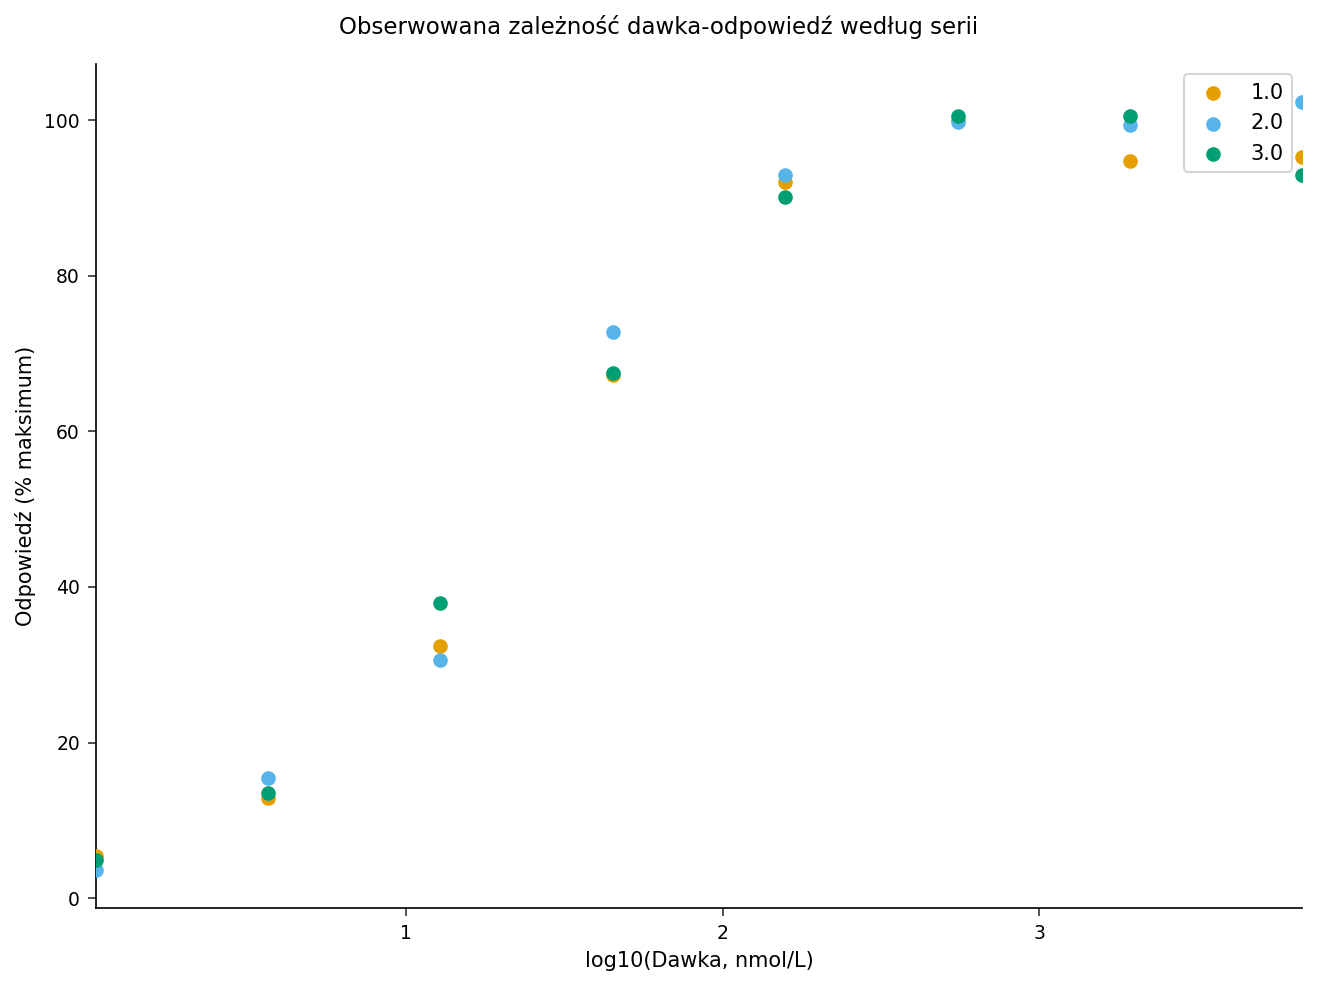

In [2]:
PROCEDURA SGPLOT DANE=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS ETYKIETA='log10(Dawka, nmol/L)';
    YAXIS ETYKIETA='Odpowiedź (% maksimum)';
    TYTUŁ 'Obserwowana zależność dawka-odpowiedź według serii';
WYKONAJ;
TYTUŁ;

## Krok 3 — Dopasowanie modelu 4PL za pomocą PROC NLIN

Deklarujemy wartości początkowe za pomocą `PARMS` (na podstawie wykresu punktowego), definiujemy średnią 4PL w pośrednim przypisaniu i przekazujemy ją do instrukcji `MODEL`. Fizycznie sensowne `BOUNDS` utrzymują asymptoty w kolejności oraz EC50 i nachylenie dodatnie, co stabilizuje iteracje Gaussa-Newtona. Instrukcja `OUTPUT` zapisuje wartości przewidywane, reszty i granice ufności do późniejszej diagnostyki, a `PLOTS=` żąda paneli dopasowania i diagnostyki.

In [3]:
PROCEDURA nlin DANE=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* Utrzymanie parametrów w fizycznie sensownych zakresach */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Czteroparametrowa odpowiedź logistyczna (wstawiona bezpośrednio: PROC NLIN
       w Jenner nie obsługuje jeszcze odwołania do pośredniej zmiennej instrukcji
       programowej w MODEL -- patrz tests/400986 -- dlatego wstawiamy mianownik wprost) */
    MODEL response = D + (A - D) / (1 + (dose / C) ** B);

    ETYKIETA response='Odpowiedź (% maksimum)' dose='Dawka (nmol/L)';

    WYJŚCIE out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
WYKONAJ;


                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/a4962766-4623-43dc-88fb-9019c9603a3e/fit4pl.avro


## Krok 4 — Raport dotyczący oszacowanego EC50 i charakterystyki krzywej

Mechanizm `OUTEST=` jest wygodny, ale dla szybkiego odczytu mocy podsumowujemy dopasowaną krzywą bezpośrednio. Tutaj zestawiamy wartości dopasowane przy każdej dawce z obserwowanymi odpowiedziami, aby potwierdzić, że model śledzi dane w całym zakresie rozcieńczeń.

In [4]:
PROCEDURA means DANE=fit4pl mean std MIN MAX maxdec=3;
    KLASA dose;
    ZMIENNA response pred resid;
    ETYKIETA dose='Dawka (nmol/L)' response='Zaobserwowana odpowiedź'
          pred='Wartość dopasowana' resid='Reszta';
    TYTUŁ 'Odpowiedź obserwowana vs dopasowana według dawki';
WYKONAJ;
TYTUŁ;

                                    Odpowiedź obserwowana vs dopasowana według dawki                                    

                                                  The MEANS Procedure

                                Analysis Variable : RESPONSE Zaobserwowana odpowiedź

                                           N
                       Dawka (nmol/L)    Obs         Mean      Std Dev      Minimum      Maximum
                       -------------------------------------------------------------------------
                       1.05                3        4.647        0.882        3.659        5.356
                       12.8625             3       33.651        3.825       30.572       37.932
                       157.565625          3       91.704        1.417       90.141       92.904
                       1930.17890625       3       98.207        3.051       94.746      100.511
                       3.675               3       13.931        1.311       12.860       15.3


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 5 — Nałożenie dopasowanej krzywej 4PL na obserwowane dane

Gęsta siatka predykcji tworzy gładką dopasowaną sigmoidę. Łączymy gładką krzywą ze średnimi wartościami dopasowanymi dla każdej dawki i pasmem ufności, a następnie nakładamy wszystko na obserwowane punkty, aby wizualnie ocenić dobroć dopasowania.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


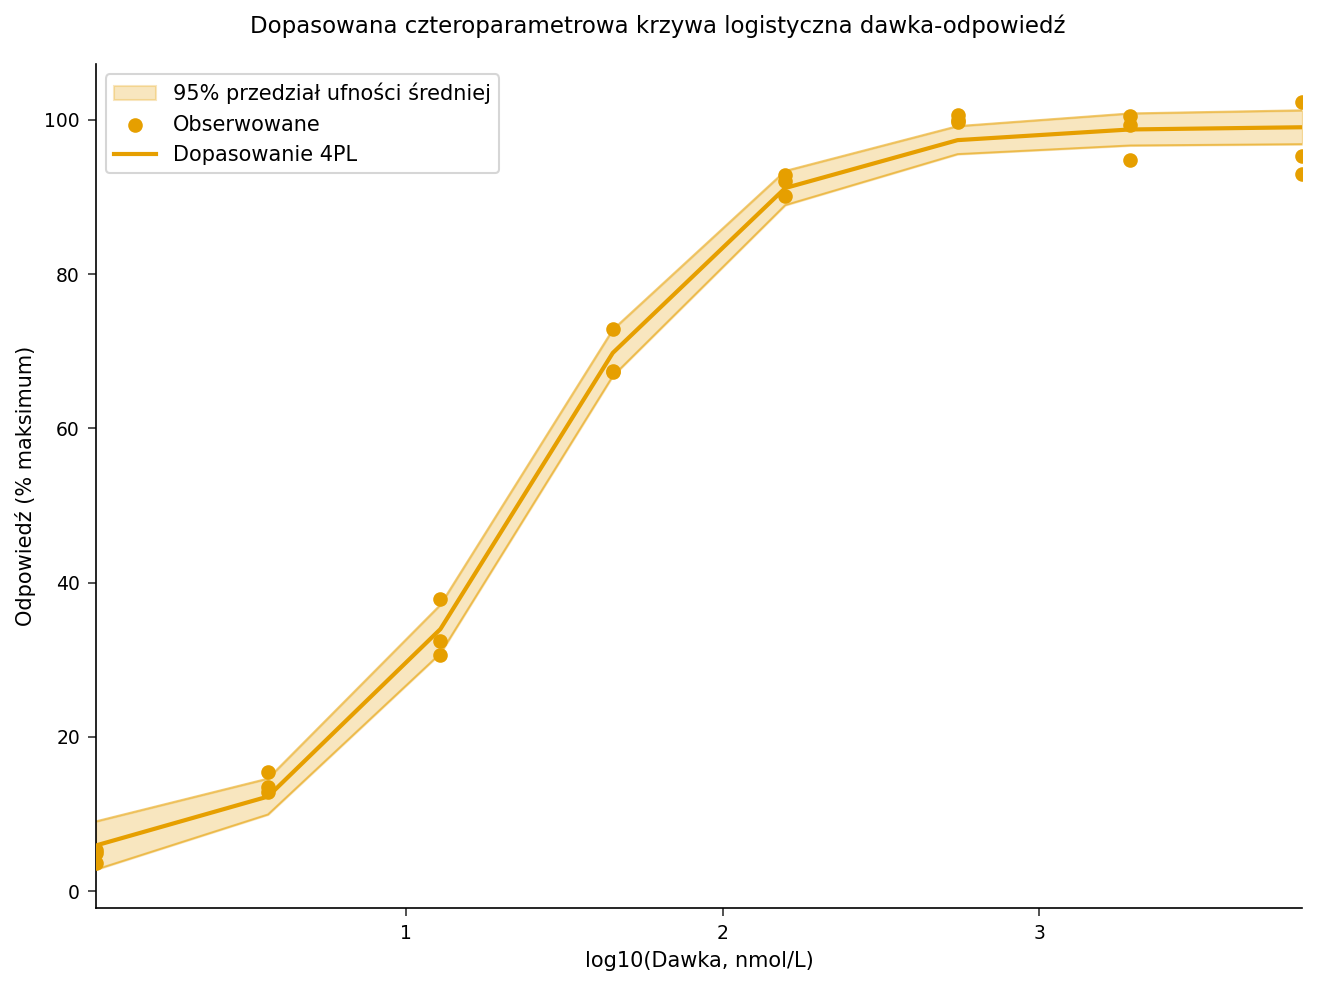

In [5]:
PROCEDURA sort DANE=fit4pl;
    WEDŁUG logdose;
WYKONAJ;

PROCEDURA SGPLOT DANE=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='95% przedział ufności średniej';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='Obserwowane';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='Dopasowanie 4PL';
    XAXIS ETYKIETA='log10(Dawka, nmol/L)';
    YAXIS ETYKIETA='Odpowiedź (% maksimum)';
    TYTUŁ 'Dopasowana czteroparametrowa krzywa logistyczna dawka-odpowiedź';
WYKONAJ;
TYTUŁ;

## Interpretacja wyników

`PROC NLIN` osiąga zbieżność do oszacowań bliskich znanym wartościom generującym: dolna asymptota bliska **5**, górna asymptota bliska **100**, **EC50 (C)** bliskie **25 nmol/L** oraz **nachylenie Hilla (B)** bliskie **1,2**. Odtworzenie tych parametrów z zaszumionych danych z trzech powtórzeń potwierdza, że model jest identyfikowalny, a ograniczenia nie były aktywne w optimum.

**EC50** jest głównym wskaźnikiem mocy: niższe wartości wskazują na silniejszy związek, a w teście mocy względnej EC50 badanej serii porównuje się ze standardem referencyjnym. **Nachylenie Hilla** charakteryzuje kooperatywność i stromość testu — nachylenie bliskie 1 jest zgodne z prostym wiązaniem do pojedynczego miejsca. **Asymptoty** definiują zakres dynamiczny testu; stabilny, dobrze rozdzielony dół i góra są warunkiem wstępnym dla walidowalnego testu biologicznego.

Wykres dopasowania pokazuje sigmoidę przechodzącą przez chmurę obserwowanych punktów z wąskim 95% pasmem ufności średniej w regionie reaktywnym, a diagnostyka reszt nie powinna wykazywać systematycznej krzywizny — co świadczy o adekwatności postaci 4PL. W praktyce można rozszerzyć ten przepływ pracy o przedziały wiarygodności `PROFILE` dla EC50, instrukcję `BOOTSTRAP` do wnioskowania o parametrach niezależnego od rozkładu lub analizę linii równoległych porównującą serie badaną i referencyjną w celu oszacowania mocy względnej.